$n = 3$ の場合の回路を実装する

In [25]:
from sympy import *
from sympy.physics.quantum import *
from sympy.physics.quantum.qubit import Qubit,QubitBra
init_printing() # ベクトルや行列を綺麗に表示するため
from sympy.physics.quantum.gate import X,Y,Z,H,S,T,CNOT,SWAP,CPHASE,CGateS

$|x\rangle = \sum_{j=0}^{7} \frac{1}{\sqrt{8}} |j\rangle$ というすべての状態の重ね合わせを考える

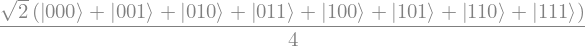

In [26]:
input = 1 / sqrt(8) * (Qubit("000") + Qubit("001") + Qubit("010") + Qubit("011") + Qubit("100") + Qubit("101") + Qubit("110") + Qubit("111"))
input

状態のベクトル表現

各状態は、対応するインデックスの部屋だけが `1` になるベクトルとして表される。
* $|000\rangle$（0番目） = `[1, 0, 0, 0, 0, 0, 0, 0]`
* $|111\rangle$（7番目） = `[0, 0, 0, 0, 0, 0, 0, 1]`

$$ |\psi\rangle = \frac{1}{\sqrt{8}} \sum_{j=0}^{7} |j\rangle = \frac{1}{\sqrt{8}} (|000\rangle + |001\rangle + \dots + |111\rangle) $$

これを足し合わせると、すべての成分が $\frac{1}{\sqrt{8}}$ になる8次元ベクトルが完成する。
$$ |\psi\rangle = \begin{pmatrix} 1/\sqrt{8} \\ 1/\sqrt{8} \\ \vdots \\ 1/\sqrt{8} \end{pmatrix} $$

In [27]:
import numpy as np
input_np_array = 1/np.sqrt(8) * np.ones(8)
print( input_np_array) 
print( np.fft.ifft(input_np_array) * np.sqrt(8) )

[0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


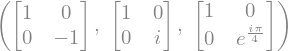

In [28]:
represent(Z(0),nqubits=1), represent(S(0),nqubits=1), represent(T(0),nqubits=1)

$R_1,R_2,R_3$ゲートはそれぞれ$Z,S,T$ゲートに等しい

In [29]:
QFT_gate = H(2) # 左から1番目の量子ビットにアダマールゲートを作用
QFT_gate = CGateS(1, S(2)) * QFT_gate # 左から2番目のビットが制御ビット
QFT_gate = CGateS(0, T(2)) * QFT_gate # 左から3番目のビットが制御ビット

In [30]:
QFT_gate = H(1) * QFT_gate # 左から2番目の量子ビットにアダマールゲートを作用
QFT_gate = CGateS(0, S(1)) * QFT_gate

In [31]:
QFT_gate = H(0) * QFT_gate # 左から3番目の量子ビットにアダマールゲートを作用

In [32]:
QFT_gate = SWAP(0, 2) * QFT_gate

In [33]:
QFT_gate

In [34]:
simplify( qapply( QFT_gate * input ))